# Gradient Descent



In [7]:
import numpy as np

class MyMultipleLinRegGD:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None   
        self.intercept_ = None 
        self.history = []
        
    def fit(self, X_train, y_train):
        # 1. Insert the column of 1s just like you did before
        X_train = np.insert(X_train, 0, 1, axis=1)
        
        # Determine the number of rows for our average calculation later
        m = X_train.shape[0]

        # 2. Start completely blind: initializing all betas (slopes + intercept) to 0
        betas = np.zeros(X_train.shape[1])

        # 3. The Training Loop (walking down the mountain)
        for epoch in range(self.epochs):
            # Calculate current guesses based on where we are on the mountain
            y_hat = np.dot(X_train, betas)
            
            # Find the distance between our guesses and the actual answers
            error = y_hat - y_train
            
            # Calculate the derivative to figure out which way is downhill
            # Note: We multiply X_train.T with the error to find the slope for EACH feature!
            gradient = (1/m) * np.dot(X_train.T, error)
            
            # Take a step! Update the old betas using the Learning Rate
            betas = betas - (self.lr * gradient)

            if epoch % 500 == 0:
                self.history.append((betas[0], betas[1].copy()))

        # 4. Extract intercept and slopes
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self, X_test):
        # Your brilliant prediction method remains completely untouched!
        y_pred = np.dot(X_test, self.coef_) + self.intercept_
        return y_pred


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Load the data
df = pd.read_csv("IceCreamData.csv")

# 2. Extract X and y
# CRITICAL: We use double brackets [['Temperature']] so X remains a 2D matrix!
X = df[['Temperature']].values
y = df['Revenue'].values

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train YOUR Gradient Descent Model
# We use a tiny learning rate so we don't accidentally "jump over" the valley
gd_model = MyMultipleLinRegGD(learning_rate=0.001, epochs=5000)
gd_model.fit(X_train, y_train)

print("--- YOUR GRADIENT DESCENT RESULTS ---")
print(f"Intercept (b): {gd_model.intercept_}")
print(f"Slope (m):     {gd_model.coef_[0]}")

# 5. Make predictions and evaluate
gd_preds = gd_model.predict(X_test)
print(f"R-Squared:     {r2_score(y_test, gd_preds)}\n")


# ---------------------------------------------------------
# BONUS: Let's compare it to Scikit-Learn's perfect math!
# ---------------------------------------------------------
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

print("--- SCIKIT-LEARN RESULTS ---")
print(f"Intercept (b): {sk_model.intercept_}")
print(f"Slope (m):     {sk_model.coef_[0]}")
print(f"R-Squared:     {r2_score(y_test, sk_model.predict(X_test))}")


--- YOUR GRADIENT DESCENT RESULTS ---
Intercept (b): 28.96839122277101
Slope (m):     22.016032804739595
R-Squared:     0.9684324802626384

--- SCIKIT-LEARN RESULTS ---
Intercept (b): 39.46449903254745
Slope (m):     21.673910401295576
R-Squared:     0.9690009112165572


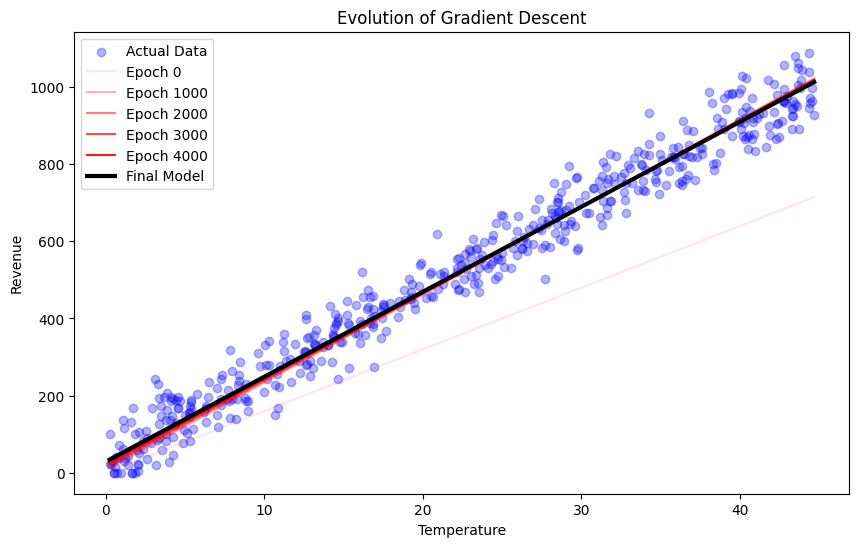

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Plot all the raw Ice Cream dots
plt.scatter(X, y, color='blue', alpha=0.3, label='Actual Data')

# 2. To draw a line, we just need the minimum and maximum Temperature values
X_line = np.array([[X.min()], [X.max()]])

# 3. Time travel: Loop through our saved history and draw the old lines!
for idx, (old_intercept, old_slope) in enumerate(gd_model.history):
    
    # Simple y = mx + b math to find the points for the line
    Y_line = (X_line * old_slope) + old_intercept
    
    # Make early lines faint, and newer lines darker red
    alpha_opacity = (idx + 1) / len(gd_model.history) 
    
    # We only label every 1000 epochs to keep the legend clean
    label_name = f'Epoch {idx * 500}' if idx % 2 == 0 else ""
    plt.plot(X_line, Y_line, color='red', alpha=alpha_opacity, label=label_name)

# 4. Draw the Final, fully trained line in thick black
Y_final = (X_line * gd_model.coef_[0]) + gd_model.intercept_
plt.plot(X_line, Y_final, color='black', linewidth=3, label='Final Model')

# Add titles and legend
plt.title("Evolution of Gradient Descent")
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.legend()
plt.show()
